In [133]:
import gymnasium as gym
import yaml
import numpy as np
import matplotlib.pyplot as plt

In [134]:
with open("env.yaml","r",encoding="utf-8") as file:
    conf = yaml.safe_load(file)

conf

{'env': {'rows': 5,
  'cols': 5,
  'slip_probability': 0.0,
  'step_reward': -0.04,
  'goal_reward': 1.0},
 'training': {'gamma': 0.95,
  'alpha': 0.1,
  'epsilon_start': 1.0,
  'epsilon_end': 0.05,
  'epsilon_decay': 0.995,
  'episodes': 3000,
  'seed': 42}}

In [135]:
slip_probability=conf["env"]["slip_probability"]
step_reward = conf["env"]["step_reward"]
goal_reward = conf["env"]["goal_reward"]
gamma = conf["training"]["gamma"]
alpha = conf["training"]["alpha"]
epsilon_start = conf["training"]["epsilon_start"]
epsilon_end = conf["training"]["epsilon_end"]
epsilon_decay = conf["training"]["epsilon_decay"]
episodes = conf["training"]["episodes"]
alpha

0.1

In [136]:
env = gym.make("FrozenLake-v1")
env

<TimeLimit<OrderEnforcing<PassiveEnvChecker<FrozenLakeEnv<FrozenLake-v1>>>>>

In [137]:
env.observation_space

Discrete(16)

In [138]:
def Epsilon_gredy(Q,state,eps):
    if np.random.random()<eps:
        return np.random.randint(4)
    else:
        return np.argmax(Q[state])

In [139]:
Q = np.zeros((16,4))
state = env.reset()
eps = epsilon_start
action = Epsilon_gredy(Q,state,eps)
print(state)

(0, {'prob': 1})


In [140]:
#Sarsa
Q = np.zeros((16,4))
eps = epsilon_start

for epoch in range(episodes):
    state, _ = env.reset()
    done = False

    while not done:
        action = Epsilon_gredy(Q,state,eps)

        next_state, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated

        next_action = Epsilon_gredy(Q,next_state,eps)

        Q[state][action] += alpha*(reward + gamma*Q[next_state][next_action] - Q[state][action])

        state = next_state
        action = next_action

    eps = max(eps*epsilon_decay,epsilon_end)
    print(f"Episode {epoch} complete")

Episode 0 complete
Episode 1 complete
Episode 2 complete
Episode 3 complete
Episode 4 complete
Episode 5 complete
Episode 6 complete
Episode 7 complete
Episode 8 complete
Episode 9 complete
Episode 10 complete
Episode 11 complete
Episode 12 complete
Episode 13 complete
Episode 14 complete
Episode 15 complete
Episode 16 complete
Episode 17 complete
Episode 18 complete
Episode 19 complete
Episode 20 complete
Episode 21 complete
Episode 22 complete
Episode 23 complete
Episode 24 complete
Episode 25 complete
Episode 26 complete
Episode 27 complete
Episode 28 complete
Episode 29 complete
Episode 30 complete
Episode 31 complete
Episode 32 complete
Episode 33 complete
Episode 34 complete
Episode 35 complete
Episode 36 complete
Episode 37 complete
Episode 38 complete
Episode 39 complete
Episode 40 complete
Episode 41 complete
Episode 42 complete
Episode 43 complete
Episode 44 complete
Episode 45 complete
Episode 46 complete
Episode 47 complete
Episode 48 complete
Episode 49 complete
Episode 50

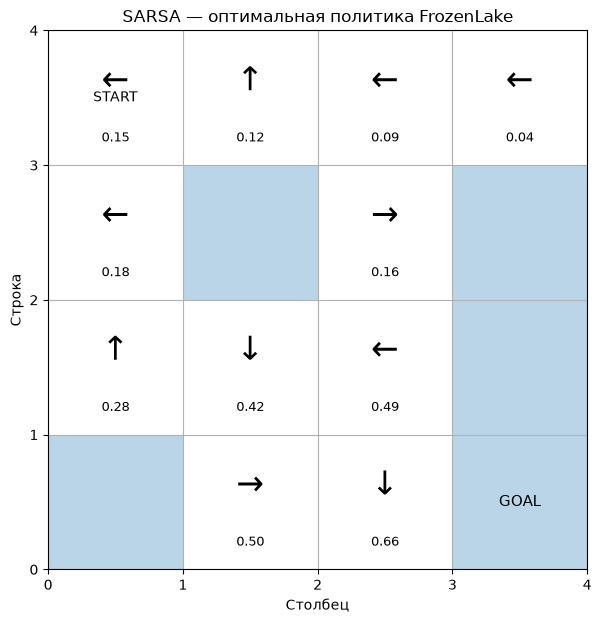

In [141]:

best_actions = np.argmax(Q, axis=1)
best_values = np.max(Q, axis=1)

# Действия FrozenLake:
# 0 = LEFT
# 1 = DOWN
# 2 = RIGHT
# 3 = UP

arrows = {
    0: "←",
    1: "↓",
    2: "→",
    3: "↑"
}

# Карта FrozenLake
desc = env.unwrapped.desc

size = 4

fig, ax = plt.subplots(figsize=(7, 7))

ax.set_xlim(0, size)
ax.set_ylim(0, size)

ax.set_xticks(np.arange(size + 1))
ax.set_yticks(np.arange(size + 1))

ax.grid(True)
ax.set_aspect("equal")


# -------------------------
# Карта FrozenLake
# -------------------------

for r in range(size):
    for c in range(size):

        cell = desc[r, c]

        x = c
        y = size - 1 - r

        # Яма
        if cell == b"H":
            ax.add_patch(
                plt.Rectangle(
                    (x, y),
                    1,
                    1,
                    alpha=0.3
                )
            )

        # Цель
        elif cell == b"G":
            ax.add_patch(
                plt.Rectangle(
                    (x, y),
                    1,
                    1,
                    alpha=0.3
                )
            )

            ax.text(
                x + 0.5,
                y + 0.5,
                "GOAL",
                ha="center",
                va="center",
                fontsize=11
            )

        # Старт
        elif cell == b"S":
            ax.text(
                x + 0.5,
                y + 0.5,
                "START",
                ha="center",
                va="center",
                fontsize=10
            )


# -------------------------
# Стрелки и Q-значения
# -------------------------

for r in range(size):
    for c in range(size):

        state = r * size + c

        cell = desc[r, c]

        x = c
        y = size - 1 - r

        # Не рисуем стрелку в яме
        if cell == b"H":
            continue

        # Не рисуем стрелку в цели
        if cell == b"G":
            continue

        action = best_actions[state]
        value = best_values[state]

        # Стрелка
        ax.text(
            x + 0.5,
            y + 0.62,
            arrows[action],
            ha="center",
            va="center",
            fontsize=24
        )

        # Максимальное Q-значение
        ax.text(
            x + 0.5,
            y + 0.2,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=9
        )


ax.set_title("SARSA — оптимальная политика FrozenLake")
ax.set_xlabel("Столбец")
ax.set_ylabel("Строка")

plt.show()

In [142]:
Q = np.zeros((16,4))
eps= epsilon_start

for epoch in range(episodes):
    state,_ = env.reset()
    done = False

    while not done:
        action = Epsilon_gredy(Q,state,eps)

        next_state, reward ,terminated, truncated, info = env.step(action)
        done = terminated or truncated
        if done:
            target = reward
        else:
            target = reward + gamma*np.argmax(Q[next_state])

        Q[state][action] += alpha*(reward + target - Q[state][action])

        state = next_state
    eps = max(eps*epsilon_decay,epsilon_end)

    print(f"Episode {epoch} complete")

Episode 0 complete
Episode 1 complete
Episode 2 complete
Episode 3 complete
Episode 4 complete
Episode 5 complete
Episode 6 complete
Episode 7 complete
Episode 8 complete
Episode 9 complete
Episode 10 complete
Episode 11 complete
Episode 12 complete
Episode 13 complete
Episode 14 complete
Episode 15 complete
Episode 16 complete
Episode 17 complete
Episode 18 complete
Episode 19 complete
Episode 20 complete
Episode 21 complete
Episode 22 complete
Episode 23 complete
Episode 24 complete
Episode 25 complete
Episode 26 complete
Episode 27 complete
Episode 28 complete
Episode 29 complete
Episode 30 complete
Episode 31 complete
Episode 32 complete
Episode 33 complete
Episode 34 complete
Episode 35 complete
Episode 36 complete
Episode 37 complete
Episode 38 complete
Episode 39 complete
Episode 40 complete
Episode 41 complete
Episode 42 complete
Episode 43 complete
Episode 44 complete
Episode 45 complete
Episode 46 complete
Episode 47 complete
Episode 48 complete
Episode 49 complete
Episode 50

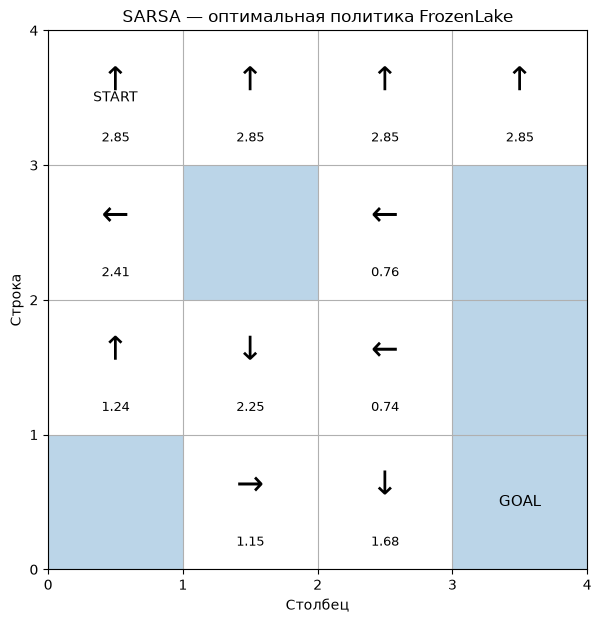

In [ ]:

best_actions = np.argmax(Q, axis=1)
best_values = np.max(Q, axis=1)

# Действия FrozenLake:
# 0 = LEFT
# 1 = DOWN
# 2 = RIGHT
# 3 = UP

arrows = {
    0: "←",
    1: "↓",
    2: "→",
    3: "↑"
}

# Карта FrozenLake
desc = env.unwrapped.desc

size = 4

fig, ax = plt.subplots(figsize=(7, 7))

ax.set_xlim(0, size)
ax.set_ylim(0, size)

ax.set_xticks(np.arange(size + 1))
ax.set_yticks(np.arange(size + 1))

ax.grid(True)
ax.set_aspect("equal")


# -------------------------
# Карта FrozenLake
# -------------------------

for r in range(size):
    for c in range(size):

        cell = desc[r, c]

        x = c
        y = size - 1 - r

        # Яма
        if cell == b"H":
            ax.add_patch(
                plt.Rectangle(
                    (x, y),
                    1,
                    1,
                    alpha=0.3
                )
            )

        # Цель
        elif cell == b"G":
            ax.add_patch(
                plt.Rectangle(
                    (x, y),
                    1,
                    1,
                    alpha=0.3
                )
            )

            ax.text(
                x + 0.5,
                y + 0.5,
                "GOAL",
                ha="center",
                va="center",
                fontsize=11
            )

        # Старт
        elif cell == b"S":
            ax.text(
                x + 0.5,
                y + 0.5,
                "START",
                ha="center",
                va="center",
                fontsize=10
            )


# -------------------------
# Стрелки и Q-значения
# -------------------------

for r in range(size):
    for c in range(size):

        state = r * size + c

        cell = desc[r, c]

        x = c
        y = size - 1 - r

        # Не рисуем стрелку в яме
        if cell == b"H":
            continue

        # Не рисуем стрелку в цели
        if cell == b"G":
            continue

        action = best_actions[state]
        value = best_values[state]

        # Стрелка
        ax.text(
            x + 0.5,
            y + 0.62,
            arrows[action],
            ha="center",
            va="center",
            fontsize=24
        )

        # Максимальное Q-значение
        ax.text(
            x + 0.5,
            y + 0.2,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=9
        )


ax.set_title("Q— оптимальная политика FrozenLake")
ax.set_xlabel("Столбец")
ax.set_ylabel("Строка")

plt.show()